Cargue el conjunto de datos de Diabetes usando load_diabetes del paquete
sklearn.datasets

In [17]:
# Importar librerías
import pandas as pd
from sklearn.datasets import load_diabetes

# Cargar el dataset
diabetes = load_diabetes()
diabetes
#Datos estandarizados
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
nombres=X.columns
print(f"Nombres de las columnas: {nombres}")
#de S1 a S6 son medciones de sangre
print(X.head())







Nombres de las columnas: Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str')
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [18]:
y=pd.DataFrame(diabetes.target, columns=["target"])
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [19]:
print(y.values)







[[151.]
 [ 75.]
 [141.]
 [206.]
 [135.]
 [ 97.]
 [138.]
 [ 63.]
 [110.]
 [310.]
 [101.]
 [ 69.]
 [179.]
 [185.]
 [118.]
 [171.]
 [166.]
 [144.]
 [ 97.]
 [168.]
 [ 68.]
 [ 49.]
 [ 68.]
 [245.]
 [184.]
 [202.]
 [137.]
 [ 85.]
 [131.]
 [283.]
 [129.]
 [ 59.]
 [341.]
 [ 87.]
 [ 65.]
 [102.]
 [265.]
 [276.]
 [252.]
 [ 90.]
 [100.]
 [ 55.]
 [ 61.]
 [ 92.]
 [259.]
 [ 53.]
 [190.]
 [142.]
 [ 75.]
 [142.]
 [155.]
 [225.]
 [ 59.]
 [104.]
 [182.]
 [128.]
 [ 52.]
 [ 37.]
 [170.]
 [170.]
 [ 61.]
 [144.]
 [ 52.]
 [128.]
 [ 71.]
 [163.]
 [150.]
 [ 97.]
 [160.]
 [178.]
 [ 48.]
 [270.]
 [202.]
 [111.]
 [ 85.]
 [ 42.]
 [170.]
 [200.]
 [252.]
 [113.]
 [143.]
 [ 51.]
 [ 52.]
 [210.]
 [ 65.]
 [141.]
 [ 55.]
 [134.]
 [ 42.]
 [111.]
 [ 98.]
 [164.]
 [ 48.]
 [ 96.]
 [ 90.]
 [162.]
 [150.]
 [279.]
 [ 92.]
 [ 83.]
 [128.]
 [102.]
 [302.]
 [198.]
 [ 95.]
 [ 53.]
 [134.]
 [144.]
 [232.]
 [ 81.]
 [104.]
 [ 59.]
 [246.]
 [297.]
 [258.]
 [229.]
 [275.]
 [281.]
 [179.]
 [200.]
 [200.]
 [173.]
 [180.]
 [ 84.]
 [121.]


## Explore las correlaciones entre variables


In [20]:
corr_matrix = X.corr()
valores=corr_matrix.values
i=0
j=0
for i in range(len(valores)):
    for j in range(len(valores)):
            if valores[i][j]>0.7 and corr_matrix.columns[i]!=corr_matrix.columns[j]:
                print(f"La variable {corr_matrix.columns[i]} y {corr_matrix.columns[j]} tienen una correlación de {valores[i][j]}")
            if valores[i][j]<-0.7 and corr_matrix.columns[i]!=corr_matrix.columns[j]:
                print(f"La variable {corr_matrix.columns[i]} y {corr_matrix.columns[j]} tienen una correlación de {valores[i][j]}")
X=X.values

La variable s1 y s2 tienen una correlación de 0.8966629578104894
La variable s2 y s1 tienen una correlación de 0.8966629578104894
La variable s3 y s4 tienen una correlación de -0.7384927292583823
La variable s4 y s3 tienen una correlación de -0.7384927292583823


## Ajuste un model de regresión lineal usando OLS

$$
\hat{\beta} = (X^{T}X)^{-1} X^{T} y
$$


In [21]:
import numpy as np

y=diabetes.target

#Agregamos el intercepto B0
X=np.column_stack((np.ones(X.shape[0]), X))
print(X)

beta=np.linalg.inv(X.T@X)@X.T@y
print(f"Los coeficientes del modelo son:")
for cof in beta:
    print(cof)
print(f"Tenemos {len(beta)} coeficientes")

[[ 1.          0.03807591  0.05068012 ... -0.00259226  0.01990749
  -0.01764613]
 [ 1.         -0.00188202 -0.04464164 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 1.          0.08529891  0.05068012 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 1.          0.04170844  0.05068012 ... -0.01107952 -0.04688253
   0.01549073]
 [ 1.         -0.04547248 -0.04464164 ...  0.02655962  0.04452873
  -0.02593034]
 [ 1.         -0.04547248 -0.04464164 ... -0.03949338 -0.00422151
   0.00306441]]
Los coeficientes del modelo son:
152.1334841628959
-10.009866299811806
-239.8156436724208
519.8459200544619
324.3846455023223
-792.1756385522052
476.739021005237
101.04326793802946
177.06323767135
751.2736995570949
67.62669218370424
Tenemos 11 coeficientes


Solo usamos la librería para confirmar resultados

In [22]:
import pandas as pd
import statsmodels.api as sm

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)



X = sm.add_constant(X)

modelo2 = sm.OLS(y, X).fit()

print(print(modelo2.params))

const    152.133484
age      -10.009866
sex     -239.815644
bmi      519.845920
bp       324.384646
s1      -792.175639
s2       476.739021
s3       101.043268
s4       177.063238
s5       751.273700
s6        67.626692
dtype: float64
None


Haga análisis de significancia del modelo y elimine las variables no significativas


In [23]:
from scipy import stats

y_hat = X @ beta
residuos = y - y_hat
n,p=X.shape
sigma2 = (residuos.T @ residuos) / (n - p)
var_beta = sigma2 * np.linalg.inv(X.T @ X)
se_beta = np.sqrt(np.diag(var_beta))
t_values = beta / se_beta

Variables_Significativas=[]
p_values = 2 * (1 - stats.t.cdf(np.abs(t_values), df=n-p))


for i in range(len(beta)):
    sig = 'Significativo' if p_values[i] < 0.05 else 'No significativo'
    if p_values[i] < 0.05 and i!=0:
        Variables_Significativas.append(nombres[i-1])
    if i!=0:
        print(f"beta_{i}: coef={beta[i]:.4f}, p-value={p_values[i]:.4f} {sig} Nombre:{nombres[i-1]}")
print(Variables_Significativas)

beta_1: coef=-10.0099, p-value=0.8670 No significativo Nombre:age
beta_2: coef=-239.8156, p-value=0.0001 Significativo Nombre:sex
beta_3: coef=519.8459, p-value=0.0000 Significativo Nombre:bmi
beta_4: coef=324.3846, p-value=0.0000 Significativo Nombre:bp
beta_5: coef=-792.1756, p-value=0.0579 No significativo Nombre:s1
beta_6: coef=476.7390, p-value=0.1604 No significativo Nombre:s2
beta_7: coef=101.0433, p-value=0.6347 No significativo Nombre:s3
beta_8: coef=177.0632, p-value=0.2735 No significativo Nombre:s4
beta_9: coef=751.2737, p-value=0.0000 Significativo Nombre:s5
beta_10: coef=67.6267, p-value=0.3060 No significativo Nombre:s6
['sex', 'bmi', 'bp', 's5']


Se realizó un análisis de significancia usando p-values.
Las variables con p-value mayor a 0.05 fueron consideradas no significativas y eliminadas del modelo.
Las variables significativas fueron sex, bmi, bp y s5, por lo que se ajustó un nuevo modelo usando solo estas variables.

In [24]:
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
X_reduced = X[Variables_Significativas]
X=X_reduced.values
X=np.column_stack((np.ones(X.shape[0]), X))

beta=np.linalg.inv(X.T@X)@X.T@y
print(beta)

[ 152.13348416 -136.75795179  598.28391202  292.97218383  554.43259221]


Utilizamos la librería nada más para confirmar

In [25]:
import pandas as pd
import statsmodels.api as sm

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

X_reduced = X[Variables_Significativas]

X_reduced = sm.add_constant(X_reduced)

modelo2 = sm.OLS(y, X_reduced).fit()

print(print(modelo2.params))

const    152.133484
sex     -136.757952
bmi      598.283912
bp       292.972184
s5       554.432592
dtype: float64
None


##  Interprete los coeficientes del modelo B

Tenemos un dataset escalado y normalizado. Esto quiere decir, y nos deja asumir, que BMI tiene los efectos positivos más fuertes; en otras palabras, entre los coeficientes, el que sea más grande es el que más influye en nuestro problema. Recordando que es porque es un dataset escalado y estandarizado.

Interpretando los coeficientes resultantes, podemos concluir que a mayor BMI (índice de masa corporal), mayor será la progresión de diabetes. Lo mismo ocurre con BP (presión arterial). S5 (medición sanguínea), que suele interpretarse como el logaritmo del nivel de los triglicéridos en suero, representa un efecto importante en la proyección diabética.

Finalmente, la variable Sex tiene un coeficiente negativo. Esto sugiere que uno de los dos sexos presenta una progresión menor que el otro, porque en el dataset hay valores positivos y negativos que representan ambos sexos diferentes.


## Ejercicio (Comprimir imagen)
### 1. Cargar imagen


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# 1. Cargar imagen
img = data.astronaut()

# Convertir a float para trabajar mejor
img = img.astype(float) / 255.0



R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

print(R)
print(G)
print(B)

[[0.60392157 0.42745098 0.24705882 ... 0.49803922 0.47058824 0.49019608]
 [0.69411765 0.56470588 0.44313725 ... 0.49803922 0.48627451 0.4745098 ]
 [0.78823529 0.71372549 0.65882353 ... 0.50196078 0.49411765 0.48627451]
 ...
 [0.72941176 0.72941176 0.71764706 ... 0.         0.         0.        ]
 [0.71764706 0.71372549 0.7254902  ... 0.         0.00392157 0.        ]
 [0.72156863 0.71764706 0.70588235 ... 0.         0.00392157 0.        ]]
[[0.57647059 0.40392157 0.22745098 ... 0.47058824 0.45882353 0.46666667]
 [0.67058824 0.55294118 0.44705882 ... 0.4627451  0.45098039 0.45490196]
 [0.76078431 0.69803922 0.64705882 ... 0.47058824 0.45490196 0.44705882]
 ...
 [0.66666667 0.66666667 0.65882353 ... 0.         0.         0.        ]
 [0.6627451  0.65490196 0.64313725 ... 0.         0.00392157 0.        ]
 [0.65490196 0.64705882 0.63529412 ... 0.         0.00392157 0.        ]]
[[0.59215686 0.48627451 0.4        ... 0.45098039 0.41568627 0.43137255]
 [0.67058824 0.56078431 0.48627451 ... 

In [27]:
Ur, Sr, Vtr = np.linalg.svd(R, full_matrices=False)
Ug, Sg, Vtg = np.linalg.svd(G, full_matrices=False)
Ub, Sb, Vtb = np.linalg.svd(B, full_matrices=False)
# Función para reconstruir usando los primeros k valores singulares
def reconstruir_canal(U, S, Vt, k):
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]
    return Uk @ Sk @ Vtk

### Use distintos niveles de compresión 𝑘 = 5, 20, 50, 100 y Para cada nivel de compresión reconstruya la imagen usando los primeros k componentes de 𝑈, Σ, 𝑉


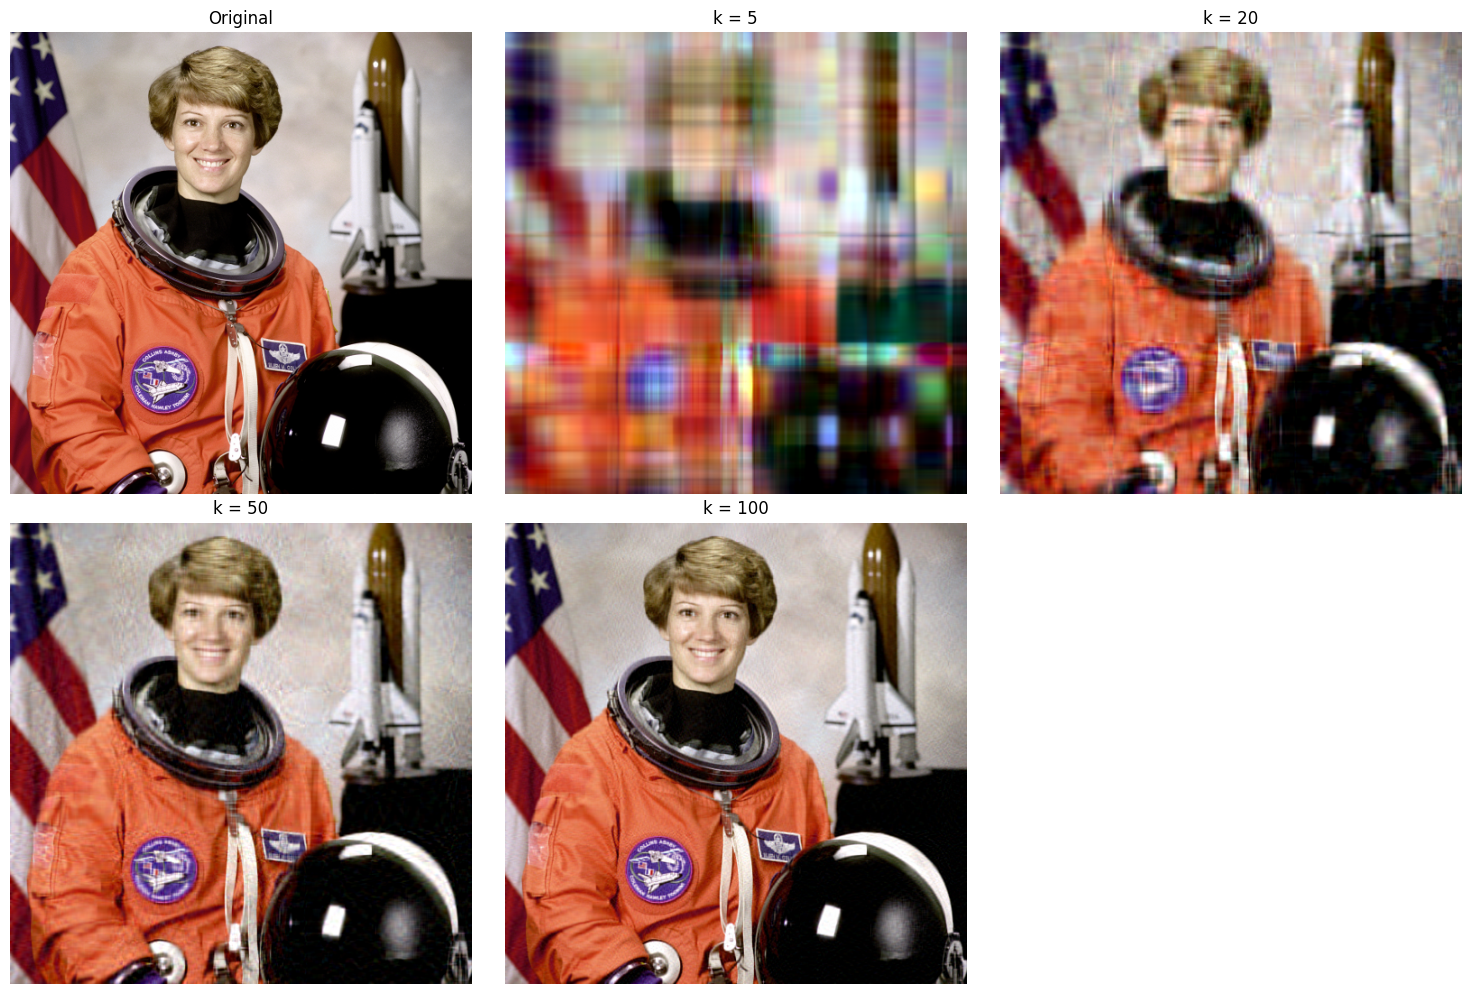

In [28]:
# Niveles de compresión pedidos
ks = [5, 20, 50, 100]

# 4. Mostrar imagen original + reconstrucciones
plt.figure(figsize=(15, 10))

# Imagen original
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

# Reconstrucciones
for i, k in enumerate(ks, start=2):
    Rk = reconstruir_canal(Ur, Sr, Vtr, k)
    Gk = reconstruir_canal(Ug, Sg, Vtg, k)
    Bk = reconstruir_canal(Ub, Sb, Vtb, k)

    img_k = np.stack([Rk, Gk, Bk], axis=2)

    # Recortar valores por seguridad al rango [0,1]
    img_k = np.clip(img_k, 0, 1)

    plt.subplot(2, 3, i)
    plt.imshow(img_k)
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()